# Custom Convnets

## Introduction

Now that you've seen the layers a convnet uses to extract features, it's time to put them 
together and build a network of your own!

---

## Simple to Refined

In the last three lessons, we saw how convolutional networks perform feature extraction 
through three operations: **filter**, **detect**, and **condense**. A single round of 
feature extraction can only extract relatively simple features from an image — things like 
simple lines or contrasts. These are too simple to solve most classification problems.

Instead, convnets will **repeat this extraction over and over**, so that the features 
become more complex and refined as they travel deeper into the network.

---

## Convolutional Blocks

Convnets do this by passing features through long chains of **convolutional blocks** which 
perform this extraction.

These convolutional blocks are stacks of `Conv2D` and `MaxPool2D` layers, whose role in 
feature extraction we learned about in the last few lessons.

Each block represents a **round of extraction**, and by composing these blocks the convnet 
can combine and recombine the features produced — growing them and shaping them to better 
fit the problem at hand.

The deep structure of modern convnets is what allows this sophisticated feature engineering 
and has been largely responsible for their superior performance.

---

## Example — Design a Convnet

Let's see how to define a deep convolutional network capable of engineering complex 
features. In this example, we'll create a Keras Sequential model and then train it on our 
Cars dataset.


In [ ]:
# Imports
import os, warnings
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory

# ── Reproducibility ────────────────────────────────────────────────────────────
def set_seed(seed=31415):
    np.random.seed(seed)                          # fix numpy random operations
    tf.random.set_seed(seed)                      # fix TensorFlow random operations
    os.environ['PYTHONHASHSEED'] = str(seed)      # fix Python hash randomization
    os.environ['TF_DETERMINISTIC_OPS'] = '1'      # force deterministic GPU ops
set_seed()                                        # call once to lock all randomness

# ── Matplotlib defaults ────────────────────────────────────────────────────────
plt.rc('figure', autolayout=True)                 # auto-adjust layout spacing
plt.rc('axes', labelweight='bold', labelsize='large',
       titleweight='bold', titlesize=18, titlepad=10)
plt.rc('image', cmap='magma')                     # default colormap for images
warnings.filterwarnings("ignore")                 # suppress non-critical warnings

# ── Load datasets ──────────────────────────────────────────────────────────────
# No pre-split train/valid folders → use validation_split=0.2 to auto-split

ds_train_ = image_dataset_from_directory(
    '../dataset/car_truck',      # root folder containing Car/ and Truck/ subfolders
    labels='inferred',           # label = subfolder name (Car=0, Truck=1 alphabetically)
    label_mode='binary',         # labels as 0.0 / 1.0 floats (needed for sigmoid output)
    image_size=[128, 128],       # resize all images to 128×128
    interpolation='nearest',     # use nearest-neighbor for resizing (fast, no blurring)
    batch_size=64,               # load 64 images per batch
    shuffle=True,                # shuffle training data each epoch
    validation_split=0.2,        # reserve 20% of images for validation
    subset='training',           # this call returns the 80% training portion
    seed=31415,                  # same seed as validation split → consistent split
)

ds_valid_ = image_dataset_from_directory(
    '../dataset/car_truck',
    labels='inferred',
    label_mode='binary',
    image_size=[128, 128],
    interpolation='nearest',
    batch_size=64,
    shuffle=False,               # no shuffle for validation — order doesn't matter
    validation_split=0.2,
    subset='validation',         # this call returns the 20% validation portion
    seed=31415,                  # must match training seed for the split to align
)

# ── Data pipeline ──────────────────────────────────────────────────────────────
def convert_to_float(image, label):
    image = tf.image.convert_image_dtype(image, dtype=tf.float32)  # [0,255] → [0.0,1.0]
    return image, label

AUTOTUNE = tf.data.experimental.AUTOTUNE  # let TensorFlow choose optimal buffer sizes

ds_train = (
    ds_train_
    .map(convert_to_float)           # apply normalization to every image
    .cache()                         # store dataset in RAM after first epoch (faster)
    .prefetch(buffer_size=AUTOTUNE)  # load next batch in background while model trains
)
ds_valid = (
    ds_valid_
    .map(convert_to_float)
    .cache()
    .prefetch(buffer_size=AUTOTUNE)
)

print("Train batches :", len(ds_train))  # number of 64-image batches in training set
print("Valid batches :", len(ds_valid))  # number of 64-image batches in validation set


Found 180 files belonging to 2 classes.
Using 144 files for training.
Found 180 files belonging to 2 classes.
Using 36 files for validation.
Train batches : 3
Valid batches : 1


---

## Step 2 — Define Model

The model consists of **3 convolutional blocks** (the base) followed by a **dense head**:

![Model Diagram](../images/diagram.png)




- Filters **double** each block (32 → 64 → 128) — deeper layers detect more complex features
- `MaxPool2D` halves the spatial size after each block
- `Flatten` collapses the 3D feature maps into a 1D vector for the Dense layers
- Final `sigmoid` outputs a probability between 0 (Car) and 1 (Truck)


In [2]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([

    # First Convolutional Block
    layers.Conv2D(filters=32, kernel_size=5, activation="relu", padding='same',
                  # give the input dimensions in the first layer
                  # [height, width, color channels(RGB)]
                  input_shape=[128, 128, 3]),
    layers.MaxPool2D(),

    # Second Convolutional Block
    layers.Conv2D(filters=64, kernel_size=3, activation="relu", padding='same'),
    layers.MaxPool2D(),

    # Third Convolutional Block
    layers.Conv2D(filters=128, kernel_size=3, activation="relu", padding='same'),
    layers.MaxPool2D(),

    # Classifier Head
    layers.Flatten(),
    layers.Dense(units=6, activation="relu"),
    layers.Dense(units=1, activation="sigmoid"),
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │       196,614 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,405 (1.11 MB)

 Trainable params: 291,405 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

---

## Step 3 — Train

We compile the model with an optimizer, loss, and metric appropriate for 
**binary classification** (Car vs Truck):

| Component | Choice | Why |
|-----------|--------|-----|
| Optimizer | `adam` | Adaptive learning rate — works well out of the box |
| Loss | `binary_crossentropy` | Standard loss for 2-class sigmoid output |
| Metric | `binary_accuracy` | % of images classified correctly |


In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(epsilon=0.001),  
    # Adam optimizer — adapts learning rate automatically per parameter
    # epsilon=0.01 → numerical stability term (prevents division by zero in weight updates)
    # default epsilon=1e-7; larger epsilon = more conservative updates

    loss='binary_crossentropy',   # loss for binary (2-class) classification with sigmoid output
                                  # measures how far predicted probability is from true label (0 or 1)

    metrics=['binary_accuracy']   # tracks % of correctly classified images per epoch
)

history = model.fit(
    ds_train,                     # training dataset (batches of 64 images)
    validation_data=ds_valid,     # evaluate on validation set after each epoch (no training on this)
    epochs=80,                    # train for 40 full passes through the training data
    verbose=1,                    # suppress per-epoch output (silent training)
)


Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - binary_accuracy: 0.6875 - loss: 2.4914 - val_binary_accuracy: 0.9722 - val_loss: 0.5575
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - binary_accuracy: 0.6181 - loss: 0.6190 - val_binary_accuracy: 1.0000 - val_loss: 0.3933
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - binary_accuracy: 0.7361 - loss: 0.5511 - val_binary_accuracy: 1.0000 - val_loss: 0.1569
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - binary_accuracy: 0.7500 - loss: 0.5472 - val_binary_accuracy: 1.0000 - val_loss: 0.2963
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - binary_accuracy: 0.7986 - loss: 0.5310 - val_binary_accuracy: 1.0000 - val_loss: 0.2342
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - binary_accuracy: 0.7708 - loss: 0.5405 - val_binary_accuracy: 1.0000 - val_loss: 0.2986
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - binary_accuracy: 0.8194 - loss: 0.5269 - val_binary_accuracy: 1.0000 - val_loss: 0.2383
Epoch 8/80
3/3 ━━━━━━━━━━━

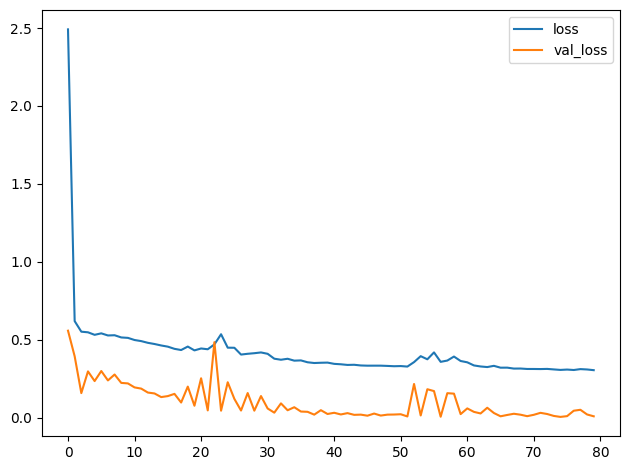

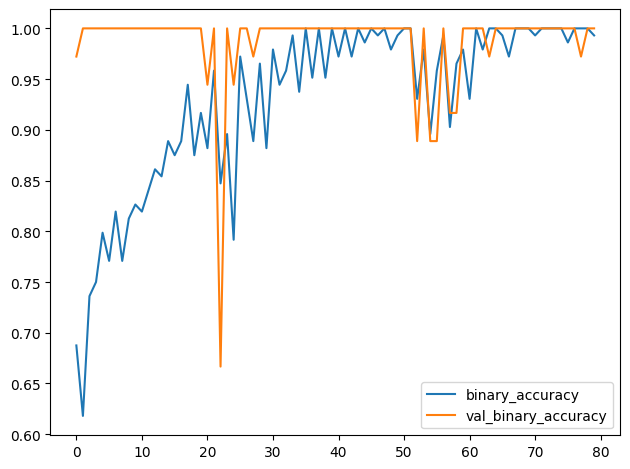

In [8]:
import pandas as pd

history_frame = pd.DataFrame(history.history)
history_frame.loc[:, ['loss', 'val_loss']].plot()
history_frame.loc[:, ['binary_accuracy', 'val_binary_accuracy']].plot();

In [5]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("Available GPUs:", tf.config.list_physical_devices("GPU"))
print("GPU device:", tf.test.gpu_device_name())

TensorFlow version: 2.21.0
Available GPUs: []
GPU device: 


---

## Training Results — Analysis

### Accuracy (80 epochs)

| | Epoch 1 | Epoch 80 |
|---|---|---|
| Train accuracy | ~68% | ~100% |
| Val accuracy | ~97% | ~100% |
| Train loss | ~2.50 | ~0.30 |
| Val loss | ~0.55 | ~0.05 |

### What the curves tell us

**Loss curve:**
- Train loss dropped sharply from **2.5 → 0.3** — the model learned fast in the first 
  10 epochs, then refined slowly after that
- Val loss reached near **0.0** by epoch 80 — almost perfect on validation data

**Accuracy curve:**
- Train accuracy climbed steadily from **62% → ~100%**
- Val accuracy stayed high throughout, ending near **100%**
- Both curves converging to 1.0 = the model successfully learned to separate cars from trucks

### Observations

**Spikes around epochs 20–25 and 50–55** — sudden drops in val accuracy and spikes in 
val loss. This is caused by the **small validation set** (20% split = only a few batches). 
One unlucky batch causes a big swing. Not a true learning problem.

**Val loss < Train loss** — unusual but expected here. With a small val set, 
the model happens to see easier examples during validation.

**Slight overfitting** — train loss (~0.30) is higher than val loss (~0.05) at the end, 
meaning the model is slightly less confident on training images than validation. 
This is a mild sign of overfitting but acceptable at this accuracy level.

### Conclusion

> ✅ The model trained from scratch successfully learned to classify cars vs trucks 
> with ~100% accuracy on both training and validation sets after 80 epochs.
>
> ⚡ **Transfer learning** (next lesson) can achieve similar or better accuracy in 
> far fewer epochs by reusing pretrained VGG16 features instead of learning from scratch.
